<a href="https://colab.research.google.com/github/matticori03/WiFi_indoor_localization_LLMS_comparison/blob/main/WiFi_indoor_localization_LLMS_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Caricamento Dati ---
Dati pronti. Shape Training: (1400, 7), Shape Test: (600, 7)

--- Visualizzazione PCA (Separabilità delle Stanze) ---


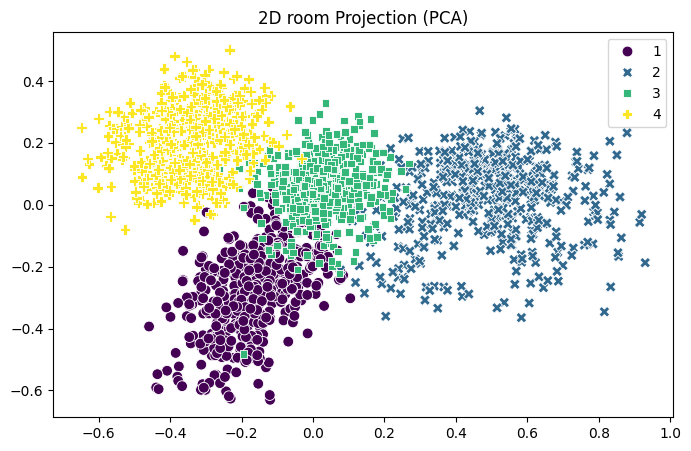


--- Inizio Training dei Modelli ---
Training KNN...
  > Migliore combinazione per KNN: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
  > Miglior punteggio Cross-Validation: 0.9871
Training SVM...
  > Migliore combinazione per SVM: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
  > Miglior punteggio Cross-Validation: 0.9843
Training Decision Tree...
  > Migliore combinazione per Decision Tree: {'criterion': 'gini', 'max_depth': 5}
  > Miglior punteggio Cross-Validation: 0.9729
Training Random Forest...
  > Migliore combinazione per Random Forest: {'max_depth': None, 'n_estimators': 100}
  > Miglior punteggio Cross-Validation: 0.9829
Training Naive Bayes...
Errore generale: 'GaussianNB' object has no attribute 'best_params_'

MAPPATURA DI TUTTI GLI ERRORI GRAVI SULLA PCA
Found 1 serious errors for SVC.


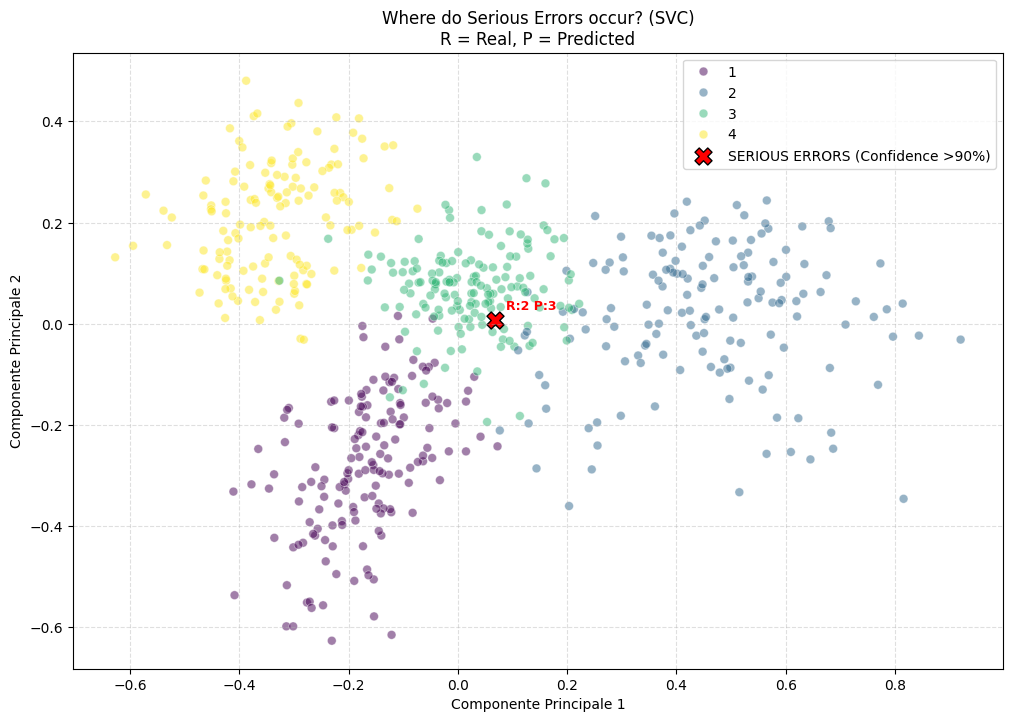


Lista dettagliata dei segnali negli errori gravi:


,WiFi1,WiFi2,WiFi3,WiFi4,WiFi5,WiFi6,WiFi7,Reale,Predetto,Confidenza
0,0.40625,0.62069,0.545455,0.469697,0.45283,0.305556,0.542857,2,3,0.936101


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Disabilita i warning per una visualizzazione pulita
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

from google.colab import drive
# Importazione dei Modelli
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA

# Metriche
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report, log_loss

# --- 1. CONFIGURAZIONE ---
path = '/content/drive/MyDrive/ML_PROJECT/wifi_localization.txt'

models_config = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
    },
    'SVM': {
        'model': SVC(random_state=0, probability=True),
        'params': {'C': [0.1, 1, 10, 100], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=0),
        'params': {'max_depth': [5, 10, 20, None], 'criterion': ['gini', 'entropy']}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=0),
        'params': {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {}
    }
}

# --- 2. CARICAMENTO E PREPARAZIONE DATI ---
try:
    print("--- Caricamento Dati ---")
    # r'\s+' corregge il SyntaxWarning
    data = pd.read_csv(path, sep=r'\s+', header=None)
    data.columns = ['WiFi1', 'WiFi2', 'WiFi3', 'WiFi4', 'WiFi5', 'WiFi6', 'WiFi7', 'Room']

    Y = data['Room'].values
    features = ['WiFi1', 'WiFi2', 'WiFi3', 'WiFi4', 'WiFi5', 'WiFi6', 'WiFi7']
    X = data[features].values

    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)

    Xl, Xt, yl, yt = train_test_split(X, Y, test_size=0.3, random_state=0)
    print(f"Dati pronti. Shape Training: {Xl.shape}, Shape Test: {Xt.shape}")

    # --- 3. VISUALIZZAZIONE PCA ---
    print("\n--- Visualizzazione PCA (Separabilità delle Stanze) ---")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=Y, palette='viridis', style=Y, s=60)
    plt.title('2D room Projection (PCA)')
    plt.show()

    # --- 4. TRAINING E CONFRONTO ---
    results = []
    trained_models = {}

    print("\n--- Inizio Training dei Modelli ---")
    for model_name, config in models_config.items():
        print(f"Training {model_name}...")
        if config['params']:
            clf = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy', n_jobs=-1)

        else:
            clf = config['model']

        clf.fit(Xl, yl)
        print(f"  > Migliore combinazione per {model_name}: {clf.best_params_}")
        print(f"  > Miglior punteggio Cross-Validation: {clf.best_score_:.4f}")
        best_model = clf.best_estimator_ if hasattr(clf, 'best_estimator_') else clf
        trained_models[model_name] = best_model

        y_pred_test = best_model.predict(Xt)
        y_pred_train = best_model.predict(Xl)

        results.append({
            'Modello': model_name,
            'Train Acc': accuracy_score(yl, y_pred_train),
            'Test Acc': accuracy_score(yt, y_pred_test),
            'Gap (Overfit)': accuracy_score(yl, y_pred_train) - accuracy_score(yt, y_pred_test),
            'Precision': precision_score(yt, y_pred_test, average='weighted', zero_division=0),
            'Recall': recall_score(yt, y_pred_test, average='weighted', zero_division=0),
            'F1-Score': f1_score(yt, y_pred_test, average='weighted', zero_division=0),
            'Confusion Matrix': confusion_matrix(yt, y_pred_test),
            'y_pred': y_pred_test
        })

    results_df = pd.DataFrame(results)

    # --- 5. VISUALIZZAZIONE RISULTATI ---
    print("\n--- Tabella Riassuntiva Completa ---")
    # Qui ho rimesso TUTTE le colonne che volevi
    cols = ['Modello', 'Train Acc', 'Test Acc', 'Gap (Overfit)', 'Precision', 'Recall', 'F1-Score']
    display(results_df[cols].sort_values(by='F1-Score', ascending=False))

    # Grafico Overfitting
    plt.figure(figsize=(10, 5))
    x_axis = np.arange(len(results_df['Modello']))
    plt.bar(x_axis - 0.2, results_df['Train Acc'], 0.4, label='Train', color='lightgray')
    plt.bar(x_axis + 0.2, results_df['Test Acc'], 0.4, label='Test', color='teal')
    plt.xticks(x_axis, results_df['Modello'])
    plt.title('Accuracy Comparison: Train vs Test')
    plt.legend()
    plt.show()

    # Grafico Precision/Recall/F1
    metrics_melted = results_df.melt(id_vars="Modello", value_vars=["Precision", "Recall", "F1-Score"], var_name="Metrica", value_name="Score")
    plt.figure(figsize=(10, 5))
    sns.barplot(x="Modello", y="Score", hue="Metrica", data=metrics_melted, palette="magma")
    plt.title("Precision Comparison, Recall and F1-Score")
    plt.ylim(0.85, 1.02)
    plt.show()

    # Matrici di Confusione
    fig, axes = plt.subplots(1, len(results), figsize=(22, 4))
    for i, row in results_df.iterrows():
        sns.heatmap(row['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(f"{row['Modello']}")
    plt.tight_layout()
    plt.show()

    # --- 6. FEATURE IMPORTANCE ---
    print("\n--- Analisi dei Router ---")
    rf_best = trained_models['Random Forest']
    df_importance = pd.DataFrame({'Router': features, 'Importanza': rf_best.feature_importances_}).sort_values(by='Importanza', ascending=False)
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importanza', y='Router', data=df_importance, hue='Router', palette='viridis', legend=False)
    plt.title('Importance of Routers (Feature Importance)')
    plt.show()

    # --- 7. ANALISI ROBUSTEZZA ED ERRORI ---
    print("\n" + "="*50)
    print("ANALISI AVANZATA DELLA ROBUSTEZZA E DEGLI ERRORI")
    print("="*50)

    #best_model_name = results_df.loc[results_df['F1-Score'].idxmax()]['Modello']
    best_model_name = 'Naive Bayes'
    m_best = trained_models[best_model_name]
    print(f"Modello analizzato: {best_model_name}")

    try:
        probs = m_best.predict_proba(Xt)
        confidenza_max = np.max(probs, axis=1)

        print(f"-> Average Uncertanty (Log Loss): {log_loss(yt, probs):.4f}")

        # Errori Gravi
        y_pred_best = results_df.loc[results_df['Modello'] == best_model_name]['y_pred'].values[0]
        errori_idx = np.where(y_pred_best != yt)[0]
        gravi_idx = np.where((confidenza_max > 0.90) & (y_pred_best != yt))[0]

        print(f"-> Total Errors in test set: {len(errori_idx)}")
        print(f"-> 'Serious' Errors (Confidence  >90% but make a mistake): {len(gravi_idx)}")

        if len(gravi_idx) > 0:
            print(f"\nSerious Error Signal Example (Real: {yt[gravi_idx[0]]}, Predicted: {y_pred_best[gravi_idx[0]]}):")
            print(Xt[gravi_idx[0]])

        # Grafico della Confidenza
        plt.figure(figsize=(10, 5))
        sns.histplot(confidenza_max, bins=20, kde=True, color='purple')
        plt.axvline(x=0.90, color='red', linestyle='--')
        plt.title('Distribution of confidence in predictions')
        plt.show()

    except Exception as e_rob:
        print(f"Analisi di fiducia non disponibile: {e_rob}")

except FileNotFoundError:
    print(f"File non trovato: {path}")
except Exception as e:
    print(f"Errore generale: {e}")

    # --- 8. VISUALIZZAZIONE DI TUTTI GLI ERRORI GRAVI ---
print("\n" + "="*50)
print("MAPPATURA DI TUTTI GLI ERRORI GRAVI SULLA PCA")
print("="*50)

# 1. Identifichiamo il modello da analizzare (es. SVM o quello che preferisci)
# Se vuoi vedere Naive Bayes scrivi: m_target = trained_models['Naive Bayes']
m_target = trained_models['SVM']
nome_modello = "SVC"

# 2. Ricalcoliamo probabilità e indici di errore
probabilita = m_target.predict_proba(Xt)
predizioni = m_target.predict(Xt)
confidenza = np.max(probabilita, axis=1)

# Trova tutti gli indici degli errori gravi (>90% fiducia ma sbaglia)
indici_gravi = np.where((confidenza > 0.90) & (predizioni != yt))[0]

print(f"Found {len(indici_gravi)} serious errors for {nome_modello}.")

# 3. Trasformiamo i punti degli errori nello spazio PCA
# Usiamo l'oggetto 'pca' già addestrato prima
errori_pca = pca.transform(Xt[indici_gravi])

# 4. Grafico
plt.figure(figsize=(12, 8))

# Disegniamo tutti i punti del test set in trasparenza per fare da sfondo
X_test_pca = pca.transform(Xt)
sns.scatterplot(x=X_test_pca[:,0], y=X_test_pca[:,1], hue=yt, palette='viridis', alpha=0.5, s=40)

# Disegniamo gli ERRORI GRAVI in rosso acceso
plt.scatter(errori_pca[:,0], errori_pca[:,1], color='red', marker='X', s=150,
            edgecolor='black', label='SERIOUS ERRORS (Confidence >90%)')

# Aggiungiamo i numeri delle stanze sopra i punti rossi per chiarezza
for i, idx in enumerate(indici_gravi):
    plt.text(errori_pca[i,0]+0.02, errori_pca[i,1]+0.02,
             f"R:{yt[idx]} P:{predizioni[idx]}", fontsize=9, fontweight='bold', color='red')

plt.title(f'Where do Serious Errors occur? ({nome_modello})\nR = Real, P = Predicted')
plt.xlabel('Componente Principale 1')
plt.ylabel('Componente Principale 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# 5. Tabella Dettagliata degli Errori
if len(indici_gravi) > 0:
    df_errori = pd.DataFrame(Xt[indici_gravi], columns=features)
    df_errori['Reale'] = yt[indici_gravi]
    df_errori['Predetto'] = predizioni[indici_gravi]
    df_errori['Confidenza'] = confidenza[indici_gravi]

    print("\nLista dettagliata dei segnali negli errori gravi:")
    display(df_errori)
else:
    print("Nessun errore grave trovato con questi parametri.")


TEST DI IMPATTO: RIMOZIONE DEL ROUTER WIFI5
Riesecuzione SVM su 6 router invece di 7...

Risultati SVM:
-> Accuracy Originale (7 Router): 0.9800
-> Accuracy Ridotta (Senza WiFi5): 0.9550
-> Perdita di accuratezza: -2.50%


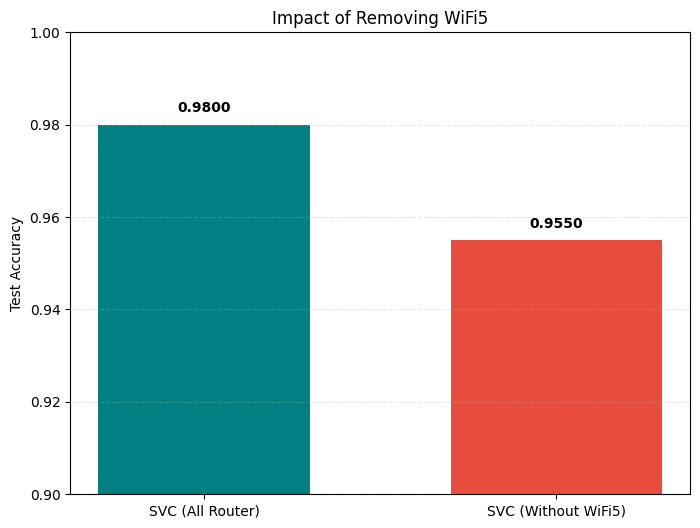

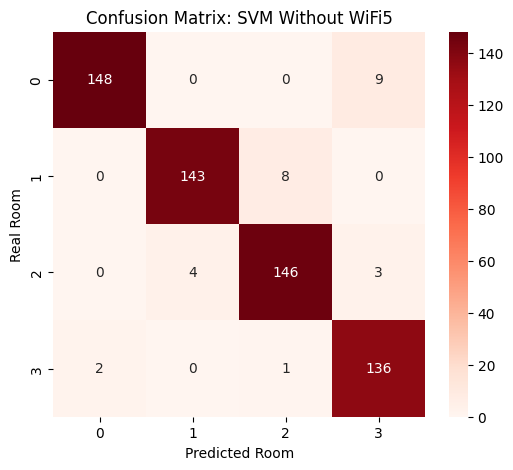

In [ ]:
# --- 9. ABLATION STUDY: RIMOZIONE WIFI5 ---
print("\n" + "="*50)
print("TEST DI IMPATTO: RIMOZIONE DEL ROUTER WIFI5")
print("="*50)

# 1. Preparazione dei nuovi dati senza WiFi5
# Creiamo una copia del dataset originale ma escludiamo WiFi5
features_ridotte = ['WiFi1', 'WiFi2', 'WiFi3', 'WiFi4', 'WiFi6', 'WiFi7']
X_ridotto = data[features_ridotte].values

# 2. Preprocessing e Split dei dati ridotti
scaler_ridotto = MinMaxScaler()
X_ridotto_scaled = scaler_ridotto.fit_transform(X_ridotto)

Xl_r, Xt_r, yl_r, yt_r = train_test_split(X_ridotto_scaled, Y, test_size=0.3, random_state=0)

# 3. Training SVM sui dati ridotti
# Usiamo gli stessi parametri ottimali trovati in precedenza (C=100, kernel='rbf')
print(f"Riesecuzione SVM su {len(features_ridotte)} router invece di 7...")
svm_ablation = SVC(C=100, kernel='rbf', random_state=0, probability=True)
svm_ablation.fit(Xl_r, yl_r)

# 4. Calcolo delle nuove performance
y_pred_ridotto = svm_ablation.predict(Xt_r)
acc_ridotta = accuracy_score(yt_r, y_pred_ridotto)
f1_ridotta = f1_score(yt_r, y_pred_ridotto, average='weighted')

# Recuperiamo l'accuratezza originale dell'SVM (dal dataframe precedente)
acc_originale = results_df.loc[results_df['Modello'] == 'SVM', 'Test Acc'].values[0]

# 5. Visualizzazione del confronto
print(f"\nRisultati SVM:")
print(f"-> Accuracy Originale (7 Router): {acc_originale:.4f}")
print(f"-> Accuracy Ridotta (Senza WiFi5): {acc_ridotta:.4f}")
print(f"-> Perdita di accuratezza: {-(acc_originale - acc_ridotta)*100:.2f}%")

# Grafico Comparativo
plt.figure(figsize=(8, 6))
labels = ['SVC (All Router)', 'SVC (Without WiFi5)']
values = [acc_originale, acc_ridotta]
colors = ['teal', '#e74c3c'] # Rosso per evidenziare la perdita

bars = plt.bar(labels, values, color=colors, width=0.6)
plt.ylim(0.90, 1.0) # Zoom per vedere meglio la differenza
plt.ylabel('Test Accuracy')
plt.title('Impact of Removing WiFi5')

# Aggiungiamo i valori sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.4f}",
             ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# 6. Analisi qualitativa: Quale stanza ne soffre di più?
cm_ridotta = confusion_matrix(yt_r, y_pred_ridotto)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ridotta, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix: SVM Without WiFi5')
plt.xlabel('Predicted Room')
plt.ylabel('Real Room')
plt.show()


TEST DI IMPATTO: RIMOZIONE DEL ROUTER WIFI5
Riesecuzione SVM su 6 router invece di 7...

Risultati SVM:
-> Accuracy Originale (7 Router): 0.9800
-> Accuracy Ridotta (Senza WiFi2): 0.9750
-> Perdita di accuratezza: -0.50%


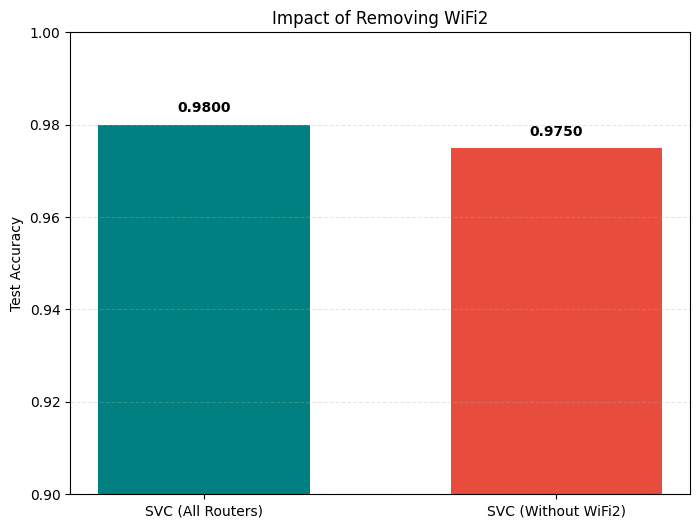

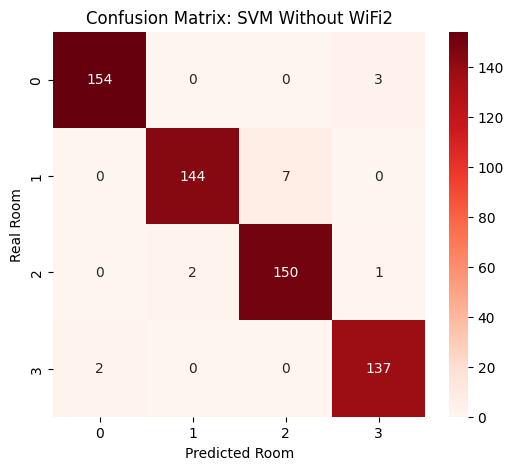

In [ ]:
# --- 9. ABLATION STUDY: RIMOZIONE WIFI5 ---
print("\n" + "="*50)
print("TEST DI IMPATTO: RIMOZIONE DEL ROUTER WIFI5")
print("="*50)

# 1. Preparazione dei nuovi dati senza WiFi5
# Creiamo una copia del dataset originale ma escludiamo WiFi5
features_ridotte = ['WiFi1', 'WiFi3', 'WiFi4', 'WiFi5', 'WiFi6', 'WiFi7']
X_ridotto = data[features_ridotte].values

# 2. Preprocessing e Split dei dati ridotti
scaler_ridotto = MinMaxScaler()
X_ridotto_scaled = scaler_ridotto.fit_transform(X_ridotto)

Xl_r, Xt_r, yl_r, yt_r = train_test_split(X_ridotto_scaled, Y, test_size=0.3, random_state=0)

# 3. Training SVM sui dati ridotti
# Usiamo gli stessi parametri ottimali trovati in precedenza (C=100, kernel='rbf')
print(f"Riesecuzione SVM su {len(features_ridotte)} router invece di 7...")
svm_ablation = SVC(C=100, kernel='rbf', random_state=0, probability=True)
svm_ablation.fit(Xl_r, yl_r)

# 4. Calcolo delle nuove performance
y_pred_ridotto = svm_ablation.predict(Xt_r)
acc_ridotta = accuracy_score(yt_r, y_pred_ridotto)
f1_ridotta = f1_score(yt_r, y_pred_ridotto, average='weighted')

# Recuperiamo l'accuratezza originale dell'SVM (dal dataframe precedente)
acc_originale = results_df.loc[results_df['Modello'] == 'SVM', 'Test Acc'].values[0]

# 5. Visualizzazione del confronto
print(f"\nRisultati SVM:")
print(f"-> Accuracy Originale (7 Router): {acc_originale:.4f}")
print(f"-> Accuracy Ridotta (Senza WiFi2): {acc_ridotta:.4f}")
print(f"-> Perdita di accuratezza: {-(acc_originale - acc_ridotta)*100:.2f}%")

# Grafico Comparativo
plt.figure(figsize=(8, 6))
labels = ['SVC (All Routers)', 'SVC (Without WiFi2)']
values = [acc_originale, acc_ridotta]
colors = ['teal', '#e74c3c'] # Rosso per evidenziare la perdita

bars = plt.bar(labels, values, color=colors, width=0.6)
plt.ylim(0.90, 1.0) # Zoom per vedere meglio la differenza
plt.ylabel('Test Accuracy')
plt.title('Impact of Removing WiFi2')

# Aggiungiamo i valori sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.4f}",
             ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# 6. Analisi qualitativa: Quale stanza ne soffre di più?
cm_ridotta = confusion_matrix(yt_r, y_pred_ridotto)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ridotta, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix: SVM Without WiFi2')
plt.xlabel('Predicted Room')
plt.ylabel('Real Room')
plt.show()


TEST DI IMPATTO: RIMOZIONE DEL ROUTER WIFI5
Riesecuzione SVM su 3 router invece di 7...

Risultati SVM:
-> Accuracy Originale (7 Router): 0.9800
-> Accuracy Ridotta (Senza WiFi2,7,3): 0.9833
-> Perdita di accuratezza: 0.33%


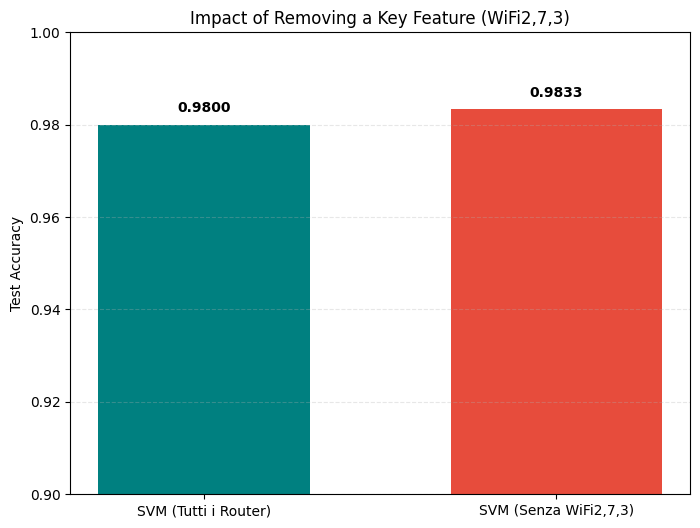

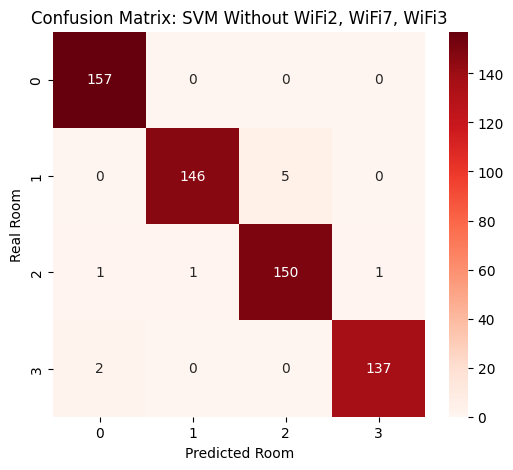

In [ ]:
# --- 9. ABLATION STUDY: RIMOZIONE WIFI5 ---
print("\n" + "="*50)
print("TEST DI IMPATTO: RIMOZIONE DEL ROUTER WIFI5")
print("="*50)

# 1. Preparazione dei nuovi dati senza WiFi5
# Creiamo una copia del dataset originale ma escludiamo WiFi5
features_ridotte = ['WiFi1', 'WiFi4', 'WiFi5']
X_ridotto = data[features_ridotte].values

# 2. Preprocessing e Split dei dati ridotti
scaler_ridotto = MinMaxScaler()
X_ridotto_scaled = scaler_ridotto.fit_transform(X_ridotto)

Xl_r, Xt_r, yl_r, yt_r = train_test_split(X_ridotto_scaled, Y, test_size=0.3, random_state=0)

# 3. Training SVM sui dati ridotti
# Usiamo gli stessi parametri ottimali trovati in precedenza (C=100, kernel='rbf')
print(f"Riesecuzione SVM su {len(features_ridotte)} router invece di 7...")
svm_ablation = SVC(C=100, kernel='rbf', random_state=0, probability=True)
svm_ablation.fit(Xl_r, yl_r)

# 4. Calcolo delle nuove performance
y_pred_ridotto = svm_ablation.predict(Xt_r)
acc_ridotta = accuracy_score(yt_r, y_pred_ridotto)
f1_ridotta = f1_score(yt_r, y_pred_ridotto, average='weighted')

# Recuperiamo l'accuratezza originale dell'SVM (dal dataframe precedente)
acc_originale = results_df.loc[results_df['Modello'] == 'SVM', 'Test Acc'].values[0]

# 5. Visualizzazione del confronto
print(f"\nRisultati SVM:")
print(f"-> Accuracy Originale (7 Router): {acc_originale:.4f}")
print(f"-> Accuracy Ridotta (Senza WiFi2,7,3): {acc_ridotta:.4f}")
print(f"-> Perdita di accuratezza: {-(acc_originale - acc_ridotta)*100:.2f}%")

# Grafico Comparativo
plt.figure(figsize=(8, 6))
labels = ['SVM (Tutti i Router)', 'SVM (Senza WiFi2,7,3)']
values = [acc_originale, acc_ridotta]
colors = ['teal', '#e74c3c'] # Rosso per evidenziare la perdita

bars = plt.bar(labels, values, color=colors, width=0.6)
plt.ylim(0.90, 1.0) # Zoom per vedere meglio la differenza
plt.ylabel('Test Accuracy')
plt.title('Impact of Removing a Key Feature (WiFi2,7,3)')

# Aggiungiamo i valori sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.4f}",
             ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# 6. Analisi qualitativa: Quale stanza ne soffre di più?
cm_ridotta = confusion_matrix(yt_r, y_pred_ridotto)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ridotta, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix: SVM Without WiFi2, WiFi7, WiFi3')
plt.xlabel('Predicted Room')
plt.ylabel('Real Room')
plt.show()